## Project 02 : K-means

In [1]:
import numpy as np

### K-Means Algorithm: Detailed Steps

In [2]:
def compute_labels(X, centroids):
    """Compute labels.

    Parameters
    ----------
    X: array-like, shape (n_samples, n_features)
        List of n_features-dimensional data points. Each row corresponds
        to a single data point.

    centroids: array-like, shape (n_clusters, n_features)
        The estimated centroids.

    Returns
    -------
    labels : array, shape (n_samples,)
        The labels of each sample
    """
    # Q1: Implement K-means
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    
    return np.argmin(distances, axis=1)


def compute_inertia_centroids(X, labels):
    """Compute inertia and centroids.

    Parameters
    ----------
    X: array-like, shape (n_samples, n_features)
        List of n_features-dimensional data points. Each row corresponds
        to a single data point.

    labels : array-like, shape (n_saples,)
        The labels of each sample.

    Returns
    -------
    inertia: float
        The inertia.

    centroids: array-like, shape (n_clusters, n_features)
        The estimated centroids.
    """
    # Q1: Implement K-means
    n_clusters = len(np.unique(labels))
    n_features = X.shape[1]
    centroids = np.zeros((n_clusters, n_features))
    inertia = 0.0
    
    for k in range(n_clusters):
        # Mask for points belonging to cluster k
        cluster_mask = (labels == k)
        cluster_points = X[cluster_mask]
        
        if len(cluster_points) > 0:
            # Update centroid: the mean of all points assigned to it
            centroids[k] = np.mean(cluster_points, axis=0)
            # Add to inertia: sum of squared distances to the new centroid
            inertia += np.sum((cluster_points - centroids[k])**2)
            
    return float(inertia), centroids


def kmeans(X, n_clusters, max_iter=100, tol=1e-7, random_state=42):
    """Estimate position of centroids and labels.

    Parameters
    ----------
    X: array-like, shape (n_samples, n_features)
        List of n_features-dimensional data points. Each row corresponds
        to a single data point.

    n_clusters: int
        The desired number of clusters.

    max_iter: int, defaults 100.
        Max number of update.

    tol: float, defaults 1e-7.
        The tolerance to check convergence.

    random_state: int, defaults to 42.
        A random number generator instance.

    Returns
    -------
    centroids: array-like, shape (n_clusters, n_features)
        The estimated centroids.

    labels: array-like, shape (n_samples,)
        The estimated labels.

    inertia: float
        The inertia.
    """
    # Q1: Implement K-means
    X = np.asarray(X)
    rng = np.random.RandomState(random_state)
    
    # Initialize centroids by picking random points from X
    initial_indices = rng.permutation(X.shape[0])[:n_clusters]
    centroids = X[initial_indices]
    
    for i in range(max_iter):
        old_centroids = centroids.copy()
        
        # Assignment Step
        labels = compute_labels(X, centroids)
        
        # Update Step
        inertia, centroids = compute_inertia_centroids(X, labels)
        
        # Check for convergence (if centroids move less than tol)
        if np.linalg.norm(centroids - old_centroids) < tol:
            break
            
    return centroids, labels, inertia

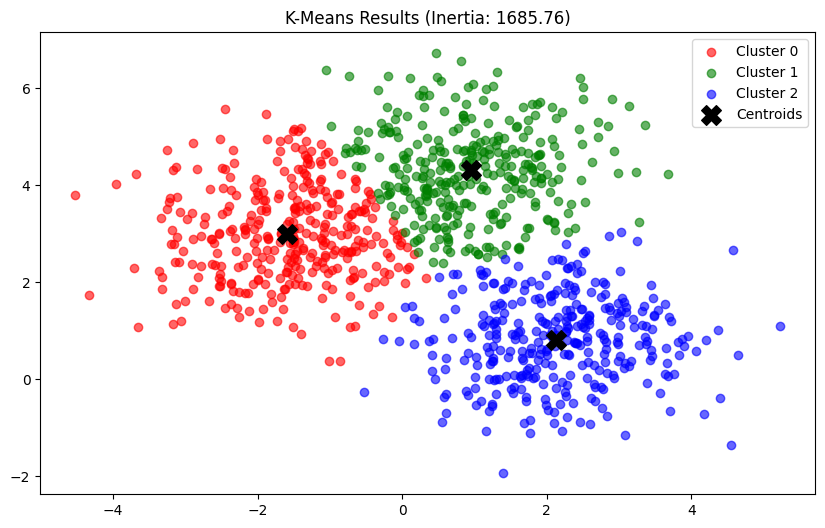

Centroids:
[[-1.59841963  2.98715524]
 [ 0.95346087  4.30374539]
 [ 2.13480346  0.81914762]]
Inertia: 1685.7644138358623


In [3]:
from matplotlib import pyplot as plt


if __name__ == '__main__':
    from sklearn.datasets import make_blobs

    # Parameters
    random_state = 0
    n_samples = 1000
    color = 'rgbcmyk'

    # Generate data
    X, y = make_blobs(n_samples=n_samples, random_state=random_state,
                      centers=3)

    # Q1-Q4 Apply K-means to X
    n_clusters = 3
    centroids, labels, inertia = kmeans(X, n_clusters=n_clusters, random_state=random_state)

    plt.figure(figsize=(10, 6))
    for i in range(n_clusters):
        plt.scatter(X[labels == i, 0], X[labels == i, 1], c=color[i], label=f'Cluster {i}', alpha=0.6)
    
    plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Centroids')
    plt.title(f"K-Means Results (Inertia: {inertia:.2f})")
    plt.legend()
    plt.show()

    print(f"Centroids:\n{centroids}")
    print(f"Inertia: {inertia}")

### Optimal Calculation of the Number of Clusters

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

### Q1

In [5]:
def compute_log_inertia(X, n_clusters, T, bb_min, bb_max,
                        random_state=0):
    """Compute the log inertia of X and X_t.

    Parameters
    ----------
    X: array-like, shape (n_samples, n_features)
        List of n_features-dimensional data points. Each row corresponds
        to a single data point.

    n_clusters: int
        The desired number of clusters.

    T: int
        Number of draws of X_t.

    bb_min: array, shape (n_features,)
        Inferior corner of the bounding box of X.

    bb_max: array, shape (n_features,)
        Superior corner of the bounding box of X.

    random_state: int, defaults to 0.
        A random number generator instance.

    Returns
    -------
    log_inertia: float
        Log of the inertia of the K-means applied to X.

    mean_log_inertia_rand: float
        Mean of the log of the inertia of the K-means applied to the different
        X_t.

    std_log_inertia_rand: float
        Standard deviation of the log of the inertia of the K-means applied to
        the different X_t.
    """
    rng = np.random.RandomState(random_state)
    n_samples, n_features = X.shape

    # Compute log inertia for the original data
    _, _, inertia = kmeans(X, n_clusters, random_state=random_state)
    log_inertia = np.log(inertia)

    # Compute log inertia for T random datasets
    log_inertias_rand = []
    for t in range(T):
        # Generate random data X_t uniformly within the bounding box
        X_t = rng.uniform(bb_min, bb_max, size=(n_samples, n_features))
        
        # Apply K-means to the random data
        _, _, inertia_t = kmeans(X_t, n_clusters, random_state=t)
        log_inertias_rand.append(np.log(inertia_t))

    # Calculate mean and standard deviation of the log inertias
    mean_log_inertia_rand = np.mean(log_inertias_rand)
    std_log_inertia_rand = np.std(log_inertias_rand)

    return log_inertia, mean_log_inertia_rand, std_log_inertia_rand

### Q2

In [6]:
def compute_gap(X, n_clusters_max, T=10, random_state=0):
    """Compute values of Gap and delta.

    Parameters
    ----------
    X: array-like, shape (n_samples, n_features)
        List of n_features-dimensional data points. Each row corresponds
        to a single data point.

    n_cluster_max: int
        Maximum number of cluster to test.

    T: int, defaults 10.
        Number of draws of X_t.

    random_state: int, defaults to 0.
        A random number generator instance.

    Returns
    -------
    n_clusters_range: array-like, shape (n_clusters_max-1,)
        Array of number of clusters tested.

    gap: array-like, shape (n_clusters_max-1,)
        Return the gap values.

    delta: array-like, shape (n_clusters_max-1,)
        Return the delta values.
    """
    n_clusters_range = np.arange(1, n_clusters_max)
    gap = np.zeros(len(n_clusters_range))
    delta = np.zeros(len(n_clusters_range))
    
    # Define the bounding box for the reference distribution
    bb_min = np.min(X, axis=0)
    bb_max = np.max(X, axis=0)
    
    for i, k in enumerate(n_clusters_range):
        # Compute log inertia for actual data and reference data
        log_Wk, mean_log_Wk_rand, std_log_Wk_rand = compute_log_inertia(
            X, k, T, bb_min, bb_max, random_state=random_state
        )
        
        # Calculate Gap(k)
        gap[i] = mean_log_Wk_rand - log_Wk
        
        # Calculate simulation error (s_k)
        # delta = s_k = sd_k * sqrt(1 + 1/T)
        delta[i] = std_log_Wk_rand * np.sqrt(1 + 1 / T)
        
    return n_clusters_range, gap, delta


### Q4

In [13]:
def plot_result(n_clusters_range, gap, delta):
    """Plot the values of Gap and delta.

    Parameters
    ----------
    n_clusters_range: array-like, shape (n_clusters_max-1,)
        Array of number of clusters tested.

    gap: array-like, shape (n_clusters_max-1,)
        Return the gap values.

    delta: array-like, shape (n_clusters_max-1,)
        Return the delta values.
    """
    plt.figure(figsize=(16, 8))
    plt.subplots_adjust(left=.05, right=.98, bottom=.08, top=.98, wspace=.15,
                        hspace=.03)

    plt.subplot(121)
    plt.plot(n_clusters_range, gap)
    plt.ylabel(r'$Gap(k)$', fontsize=18)
    plt.xlabel("Number of clusters")

    plt.subplot(122)
    for x, y in zip(n_clusters_range, delta):
        plt.bar(x - .45, y, width=0.9)
    plt.ylabel(r'$\delta(k)$', fontsize=18)
    plt.xlabel("Number of clusters")

    plt.draw()


def optimal_n_clusters_search(X, n_clusters_max, T=10, random_state=0):
    """Compute the optimal number of clusters.

    Parameters
    ----------
    X: array-like, shape (n_samples, n_features)
        List of n_features-dimensional data points. Each row corresponds
        to a single data point.

    n_cluster_max: int
        Maximum number of cluster to test.

    T: int, defaults 10.
        Number of draws of X_t.

    random_state: int, defaults to 0.
        A random number generator instance.

    Returns
    -------
    n_clusters_optimal: int
        Optimal number of clusters.
    """
    n_clusters_range, gap, delta = compute_gap(X, n_clusters_max, T, random_state)
    print(gap)
    
    plot_result(n_clusters_range, gap, delta)
    
    n_clusters_optimal = n_clusters_range[-1] # Default to max if no k satisfies condition
    
    for k_idx in range(len(n_clusters_range) - 1):
        if gap[k_idx] >= gap[k_idx + 1] - delta[k_idx + 1]:
            n_clusters_optimal = n_clusters_range[k_idx]
            break
            
    return n_clusters_optimal

In [14]:
if __name__ == '__main__':
    # Parameters
    random_state = 0
    n_samples, n_clusters_max = 1000, 10

Searching for the optimal number of clusters...
[-0.00492675  0.59730503  0.27163612  2.28377838  2.16970377  2.04130818
  2.08851143  2.08758598  2.11723769]

The optimal number of clusters determined by the Gap Statistic is: 2


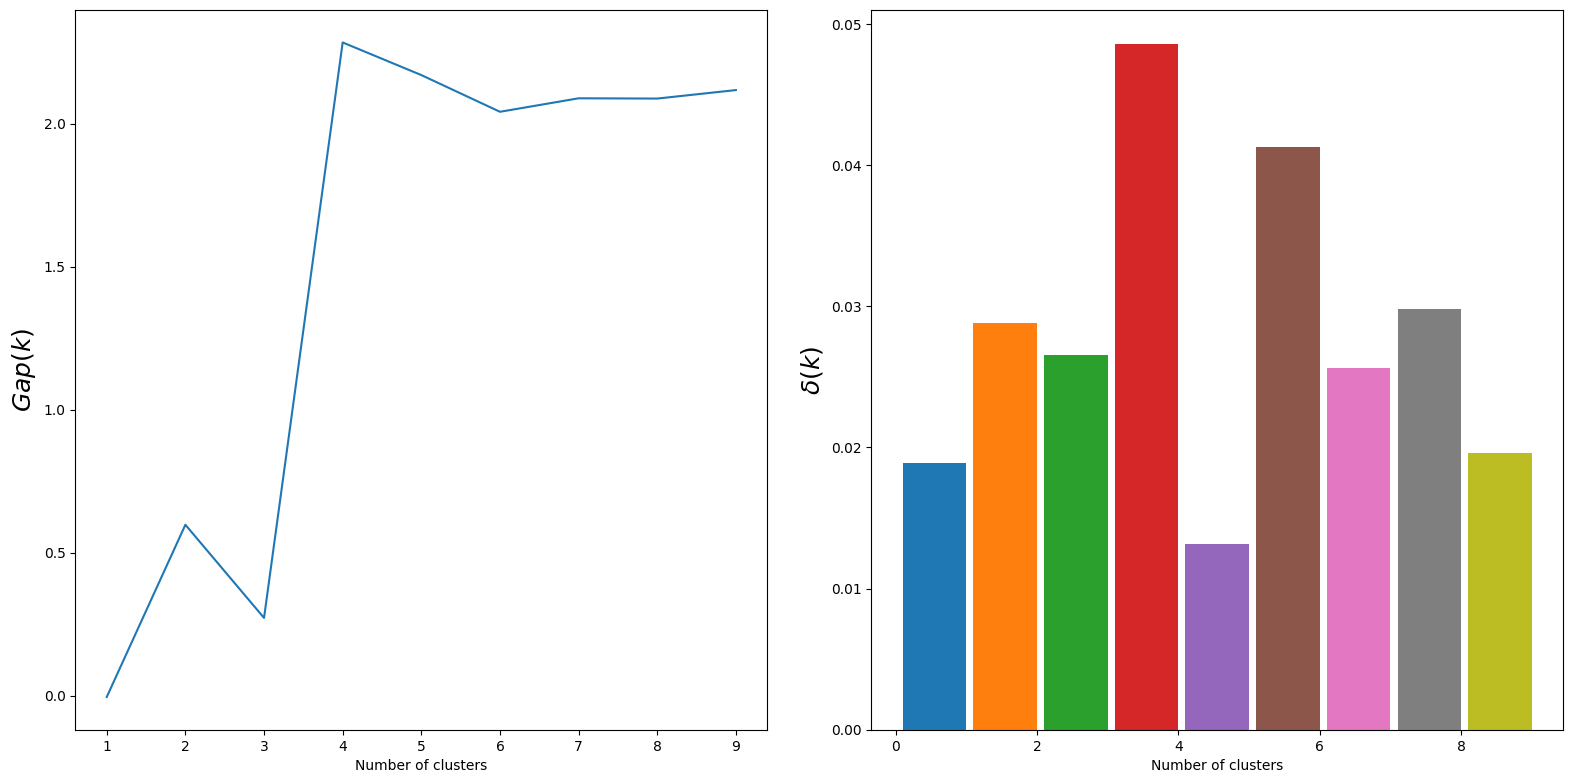

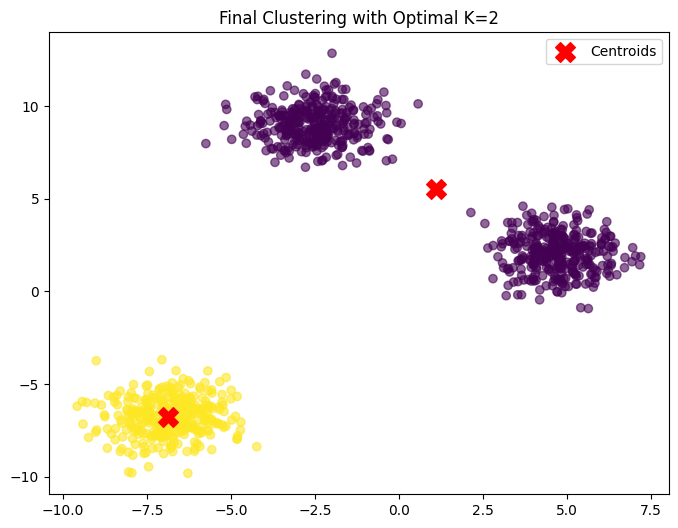

In [15]:
if __name__ == '__main__':
    from sklearn.datasets import make_blobs
    import numpy as np
    import matplotlib.pyplot as plt

    random_state = 42
    n_samples = 1000
    n_clusters_max = 10
    
    X, y = make_blobs(n_samples=n_samples, random_state=random_state, centers=3)

    print("Searching for the optimal number of clusters...")
    optimal_k = optimal_n_clusters_search(X, n_clusters_max=n_clusters_max, T=10, random_state=random_state)

    print(f"\nThe optimal number of clusters determined by the Gap Statistic is: {optimal_k}")

    centroids, labels, inertia = kmeans(X, n_clusters=optimal_k, random_state=random_state)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
    plt.title(f"Final Clustering with Optimal K={optimal_k}")
    plt.legend()
    plt.show()